# 05: Execution-based metrics (DEFERRED)

Does the translation preserve semantics? Oracle = the gold **SQL on Postgres**; compared against the generated query run on the graph DB, as multisets (Execution Accuracy / precision / recall / F1 / Jaccard).

**This notebook is DEFERRED in the first pass and gated behind `EVAL_EXECUTION=1`.** Prerequisites:

- graphonauts2 **Postgres** up (port 5433, db/user `graphonaut`) loaded with LDBC SF1.
- **Neo4j** up (`bolt://localhost:7687`, `NEO4J_PASSWORD`) loaded with LDBC SF1 (Cypher target).
- **ArangoDB** up (`http://localhost:8529`, db **`graphonauts`**, `ARANGO_PASSWORD`) loaded with LDBC SF1 (AQL target). **After every (re)load run `evaluation/build_arango_unified_edges.py`** to build the mapping-aligned unified edge collections (`KNOWS`, `HAS_CREATOR`, `HAS_TAG`, ...); without them every AQL traversal errors and execution accuracy is 0.
- **Gremlin Server** up (`ws://localhost:8182/gremlin`, TraversalSource `g`) with graphonauts2's in-memory TinkerGraph loaded (Gremlin target). TinkerGraph lives on the JVM heap: run it with Neo4j and ArangoDB **stopped**, and reload after any container restart (`uv run graphonauts load gremlin` in graphonauts2; see its `docs/gremlin/LOADING_BRIEF.md`).
- **Datetime**: Neo4j stores `creationDate`/`birthday`/`joinDate` as native temporals; ArangoDB and TinkerGraph store them as ISO-8601 strings. Both are reconciled to epoch-millis by `_to_epoch_ms` against the columns the Postgres oracle reports as dates.

Enable with: `export NEO4J_PASSWORD=... ARANGO_PASSWORD=... EVAL_EXECUTION=1` then run. Because the graph DBs cannot all run at once (memory), execution is **per target**: `EVAL_EXECUTION_TARGETS` (default `cypher,aql,gremlin`) selects which targets execute this pass, and the save cell **merges** into `metrics_execution.csv` so the other targets' rows are preserved. Comparison is **positional** (RETURN column order must match the SQL SELECT order). Cypher, AQL, and Gremlin results are reported in separate subsections below (never mixed).

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "evaluation"))

import json, os
from collections import Counter
from datetime import date, datetime
from time import perf_counter
from typing import Any
import pandas as pd
from eval_harness import load_records, OUTPUTS_DIR

EXECUTION_ENABLED = os.environ.get('EVAL_EXECUTION', '0') == '1'
if not EXECUTION_ENABLED:
    print('Execution metrics are DEFERRED. To enable:')
    print('  1. Bring up graphonauts2 Postgres (5433, graphonaut), Neo4j (7687), and')
    print('     ArangoDB (8529, db graphonauts), each with LDBC SF1.')
    print('  2. After loading ArangoDB, run evaluation/build_arango_unified_edges.py')
    print('     to build the mapping-aligned unified edge collections.')
    print('  3. export NEO4J_PASSWORD=... ARANGO_PASSWORD=... and EVAL_EXECUTION=1, then re-run.')
    raise SystemExit('EVAL_EXECUTION not set; skipping execution metrics.')

OUT_CSV = OUTPUTS_DIR / 'metrics_execution.csv'
CACHE_PATH = OUTPUTS_DIR / 'execution_rows_cache.json'
STATEMENT_TIMEOUT_S = int(os.environ.get('EVAL_QUERY_TIMEOUT', '30'))
print(f'Per-query timeout: {STATEMENT_TIMEOUT_S}s')

Per-query timeout: 180s


## Connection configs and DB availability map

Which `(dataset, target)` cells can be executed: the dataset needs a Postgres oracle, the target needs a graph DB. `cypher` runs on Neo4j, `aql` on ArangoDB (db `graphonauts`). DB passwords are asserted lazily per target on first use, so a Cypher-only or AQL-only subset needs only that backend up.

In [2]:
PG_DSN = (
    f"host={os.environ.get('POSTGRES_HOST','localhost')} "
    f"port={os.environ.get('POSTGRES_PORT','5433')} "
    f"user={os.environ.get('POSTGRES_USER','graphonaut')} "
    f"password={os.environ.get('POSTGRES_PASSWORD','password')} "
    f"dbname={os.environ.get('POSTGRES_DB','graphonaut')}"
)
NEO4J_URI = os.environ.get('NEO4J_URI', 'bolt://localhost:7687')
NEO4J_USER = os.environ.get('NEO4J_USER', 'neo4j')
NEO4J_DB = os.environ.get('NEO4J_DATABASE', 'neo4j')

# graphonauts2 loads LDBC into ArangoDB database 'graphonauts' (NOT 'ldbc', which is only the
# name used by the library's server-validation demo in config/servers/arangodb.yaml).
ARANGO_URL = os.environ.get('ARANGO_URL', 'http://localhost:8529')
ARANGO_USER = os.environ.get('ARANGO_USER', 'root')
ARANGO_DB = os.environ.get('ARANGO_DATABASE', 'graphonauts')

# graphonauts2's Gremlin Server (in-memory TinkerGraph); unauthenticated, no password.
GREMLIN_URL = os.environ.get('GREMLIN_URL', 'ws://localhost:8182/gremlin')
GREMLIN_TRAVERSAL_SOURCE = os.environ.get('GREMLIN_TRAVERSAL_SOURCE', 'g')

POSTGRES_DATASETS = {'ldbc'}                                              # datasets with a loaded Postgres oracle
TARGET_DB = {'cypher': 'neo4j', 'aql': 'arangodb', 'gremlin': 'gremlin'}  # graph DB backing each target
# Targets executed THIS pass; every other target's rows in metrics_execution.csv are
# preserved by the merge in the save cell (the backends cannot all run at once).
EXEC_TARGETS = [t.strip() for t in os.environ.get('EVAL_EXECUTION_TARGETS', 'cypher,aql,gremlin').split(',') if t.strip()]
# Passwords are asserted lazily, per target, when a runner is first used (see the executors
# cell), so a Cypher-only or AQL-only subset only needs that backend's password exported.

## Row normalisation

Canonicalise every driver value to a string so multiset comparison works across Postgres / Neo4j drivers.

In [3]:
import datetime as _dt
from neo4j.time import Date as Neo4jDate, DateTime as Neo4jDateTime

def _parse_iso(s):
    # ArangoDB returns dates as ISO strings ('2010-02-14T15:32:10.447Z' or bare '1989-12-03').
    # Parse to stdlib date/datetime so they reconcile via _to_epoch_ms; None if not a date.
    if len(s) < 10 or s[4] != '-' or s[7] != '-':
        return None
    try:
        if len(s) == 10:
            return _dt.date.fromisoformat(s)
        return _dt.datetime.fromisoformat(s.replace('Z', '+00:00'))
    except ValueError:
        return None

def _to_epoch_ms(v):
    # Canonicalise a date-typed value to epoch-millis so Postgres timestamps, Neo4j native
    # temporals (DateTime/Date), and ArangoDB ISO strings all compare equal. Also handles the
    # ISO strings that come back from the JSON reference cache.
    if isinstance(v, (Neo4jDate, Neo4jDateTime)):
        v = v.to_native()  # Neo4j temporal -> stdlib date/datetime, handled below
    if isinstance(v, str):
        parsed = _parse_iso(v)
        if parsed is not None:
            v = parsed
    if isinstance(v, _dt.datetime):
        if v.tzinfo is None:
            v = v.replace(tzinfo=_dt.timezone.utc)
        return int(v.timestamp() * 1000)
    if isinstance(v, _dt.date):
        return int(_dt.datetime(v.year, v.month, v.day, tzinfo=_dt.timezone.utc).timestamp() * 1000)
    return v

def _date_columns(rows):
    # Column positions the oracle (Postgres) returns as date/datetime.
    cols = set()
    for r in rows:
        vals = list(r.values()) if isinstance(r, dict) else list(r)
        for j, v in enumerate(vals):
            if isinstance(v, (_dt.date, _dt.datetime)):
                cols.add(j)
    return cols

def _norm_value(v, empty_as_null=False):
    if v is None:
        return None
    if empty_as_null and v == '':  # ArangoDB stores absent optional text (e.g. image-post content)
        return None                # as '' and the gold Gremlin projects NULLs via
                                   # coalesce(values(x), constant('')); both mean Postgres NULL.
    if isinstance(v, bool):
        return 'True' if v else 'False'
    if isinstance(v, (Neo4jDate, Neo4jDateTime)):
        return v.iso_format().split('+')[0].split('[')[0]
    if isinstance(v, _dt.datetime):
        return v.replace(tzinfo=None).isoformat(timespec='seconds')
    if isinstance(v, _dt.date):
        return v.isoformat()
    if isinstance(v, int):
        return str(v)
    if isinstance(v, float):
        as_int = int(v)
        return str(as_int) if abs(v - as_int) < 1e-9 else f'{v:.6f}'
    s = str(v)
    if len(s) >= 19 and s[4] == '-' and s[7] == '-' and (s[10] == 'T' or s[10] == ' '):
        return s.replace(' ', 'T')[:19]
    return s

def _norm_row(row, date_cols=frozenset(), empty_as_null=False):
    vals = list(row.values()) if isinstance(row, dict) else list(row)
    return tuple(str(_to_epoch_ms(v)) if (j in date_cols and v is not None) else _norm_value(v, empty_as_null)
                 for j, v in enumerate(vals))

## Multiset comparison

In [4]:
def compare_rowsets(ref_rows, trans_rows, date_cols=frozenset(), empty_as_null=False):
    # Oracle (Postgres) defines which columns are dates; reconcile the graph DB's epoch/ISO
    # there. `empty_as_null=True` also maps '' -> None to match Postgres NULL text columns
    # (ArangoDB stores absent text as ''; the Gremlin gold coalesces NULLs to '').
    ref = Counter(_norm_row(r, date_cols, empty_as_null) for r in ref_rows)
    trans = Counter(_norm_row(r, date_cols, empty_as_null) for r in trans_rows)
    overlap = sum((ref & trans).values())
    n_ref = sum(ref.values()); n_trans = sum(trans.values()); union = sum((ref | trans).values())
    precision = overlap / n_trans if n_trans else (1.0 if n_ref == 0 else 0.0)
    recall = overlap / n_ref if n_ref else (1.0 if n_trans == 0 else 0.0)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        'execution_accuracy': 1.0 if ref == trans else 0.0,
        'result_precision': precision, 'result_recall': recall, 'result_f1': f1,
        'result_jaccard_dist': 1.0 - (overlap / union) if union else 0.0,
        'reference_rows': n_ref, 'translated_rows': n_trans,
    }

## Query executors

`run_cypher` uses `neo4j.Query(..., timeout=...)` (the correct neo4j>=5 way to bound a query; `session.run` takes no `timeout` kwarg). `run_aql` uses `db.aql.execute(query, max_runtime=...)` (the server-side AQL cap), with the `ArangoClient` HTTP read timeout set above it. Both drivers are built lazily so each backend's password is only required when that target actually runs.

In [5]:
import psycopg
from neo4j import GraphDatabase, Query

def run_postgres(sql):
    t0 = perf_counter()
    try:
        with psycopg.connect(PG_DSN) as conn, conn.cursor() as cur:
            cur.execute(f'SET LOCAL statement_timeout = {STATEMENT_TIMEOUT_S * 1000}')
            cur.execute(sql)
            rows = cur.fetchall()
    except Exception as exc:
        return [], perf_counter() - t0, f'{type(exc).__name__}: {exc}'
    return rows, perf_counter() - t0, None

_neo4j_driver = None
def _neo4j():
    global _neo4j_driver
    if _neo4j_driver is None:
        assert os.environ.get('NEO4J_PASSWORD'), 'Export NEO4J_PASSWORD (needed for cypher records).'
        _neo4j_driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, os.environ['NEO4J_PASSWORD']))
    return _neo4j_driver

def run_cypher(query):
    t0 = perf_counter()
    try:
        with _neo4j().session(database=NEO4J_DB) as session:
            result = session.run(Query(query, timeout=STATEMENT_TIMEOUT_S))
            rows = [r.data() for r in result]
    except Exception as exc:
        return [], perf_counter() - t0, f'{type(exc).__name__}: {exc}'
    return rows, perf_counter() - t0, None

_arango_client = None
_arango_db = None
def _arango():
    global _arango_client, _arango_db
    if _arango_db is None:
        from arango import ArangoClient
        assert os.environ.get('ARANGO_PASSWORD'), 'Export ARANGO_PASSWORD (needed for aql records).'
        # HTTP read timeout kept above the server-side max_runtime so a slow query surfaces as
        # a clean AQL timeout, not an HTTP ReadTimeout.
        _arango_client = ArangoClient(hosts=ARANGO_URL, request_timeout=STATEMENT_TIMEOUT_S + 30)
        _arango_db = _arango_client.db(ARANGO_DB, username=ARANGO_USER, password=os.environ['ARANGO_PASSWORD'])
    return _arango_db

def run_aql(query):
    # AQL RETURN {...} yields dicts, same shape as run_cypher's r.data(); the comparator reads
    # them positionally (RETURN key order must match the SQL SELECT order).
    t0 = perf_counter()
    try:
        cursor = _arango().aql.execute(query, max_runtime=float(STATEMENT_TIMEOUT_S))
        rows = list(cursor)
    except Exception as exc:
        return [], perf_counter() - t0, f'{type(exc).__name__}: {exc}'
    return rows, perf_counter() - t0, None

# Gremlin runs in a fresh daemon thread per query, for two reasons:
# 1. gremlinpython's Client cannot be constructed on a thread with a RUNNING asyncio
#    loop (the Jupyter kernel's) -- it raises "Cannot run the event loop while another
#    loop is running". A fresh thread has no loop.
# 2. A lost/oversized response frame can wedge the websocket and block .result()
#    forever (observed: server and kernel both idle mid-run). The daemon thread plus a
#    client-side timeout turns any wedge into a recorded execution_error, and an
#    abandoned daemon thread cannot block interpreter shutdown.
import queue as _queue
import threading as _threading

_gremlin_client = None  # kept for the save cell's close guard; always None here

def _shape_gremlin_row(row):
    # _norm_row iterates each row (dict.values() or list(...)); a scalar Gremlin result
    # (bare count(), values() of one column) would crash it, so wrap it as a 1-tuple.
    return row if isinstance(row, (dict, list, tuple)) else (row,)

def run_gremlin(query):
    t0 = perf_counter()
    outcome = _queue.Queue()

    def _work():
        try:
            from gremlin_python.driver.client import Client
            client = Client(GREMLIN_URL, GREMLIN_TRAVERSAL_SOURCE)  # unauthenticated
            result_set = client.submit(query, request_options={'evaluationTimeout': STATEMENT_TIMEOUT_S * 1000})
            rows = [_shape_gremlin_row(r) for r in result_set.all().result(timeout=STATEMENT_TIMEOUT_S + 30)]
            client.close()
            outcome.put(('ok', rows))
        except Exception as exc:
            outcome.put(('err', f'{type(exc).__name__}: {exc}'))

    _threading.Thread(target=_work, daemon=True).start()
    try:
        kind, payload = outcome.get(timeout=STATEMENT_TIMEOUT_S + 60)
    except _queue.Empty:
        return [], perf_counter() - t0, 'ClientHang: no response within client-side timeout (connection abandoned)'
    if kind == 'err':
        return [], perf_counter() - t0, payload
    return payload, perf_counter() - t0, None

RUNNERS = {'cypher': run_cypher, 'aql': run_aql, 'gremlin': run_gremlin}

## Reference-row cache

Keyed by `(dataset, query_id)` so the same query id across datasets does not collide. Delete `execution_rows_cache.json` to refresh.

In [6]:
cache = json.loads(CACHE_PATH.read_text()) if CACHE_PATH.exists() else {}
print(f'Reference cache: {len(cache)} entries.')

Reference cache: 14 entries.


## Execution, per target

One `execute_target(target)` call runs every record of that target against its graph DB and returns the metric rows. The three subsections below run cypher / aql / gremlin independently; a target not listed in `EVAL_EXECUTION_TARGETS` is skipped (returns `None`) and keeps its existing rows in `metrics_execution.csv`.

In [7]:
records = load_records(OUTPUTS_DIR)
print(f'Loaded {len(records)} record(s); targets selected for execution: {EXEC_TARGETS}')

def execute_target(target):
    """Execute every record of one target; returns the metric rows (None if skipped)."""
    if target not in EXEC_TARGETS:
        print(f'{target}: skipped (not in EVAL_EXECUTION_TARGETS); existing rows are preserved.')
        return None
    runnable = [r for r in records if r['dataset'] in POSTGRES_DATASETS and r['target'] == target]
    print(f'{target}: {len(runnable)} executable record(s).')
    rows_out = []
    for idx, rec in enumerate(runnable, start=1):
        qid = rec['query_id']; ckey = f"{rec['dataset']}:{qid}"
        print(f'[{idx:3d}/{len(runnable)}] {qid} ({rec["target"]})', end=' ', flush=True)
        if ckey in cache:
            ref_rows = [tuple(r) for r in cache[ckey]['rows']]; ref_runtime = cache[ckey]['runtime']
            ref_error = cache[ckey].get('error'); dcols = set(cache[ckey].get('date_cols', []))
        else:
            ref_rows, ref_runtime, ref_error = run_postgres(rec['sql'])
            dcols = sorted(_date_columns(ref_rows))
            cache[ckey] = {'rows': [list(r) for r in ref_rows], 'runtime': ref_runtime,
                           'error': ref_error, 'date_cols': dcols}
            CACHE_PATH.write_text(json.dumps(cache, default=str)); dcols = set(dcols)
        out = {'dataset': rec['dataset'], 'target': rec['target'], 'model': rec['model'],
               'query_id': qid, 'difficulty': rec['difficulty'], 'validation_passed': rec['validation_passed'],
               'reference_runtime_s': ref_runtime, 'reference_error': ref_error, 'translated_runtime_s': None,
               'execution_error': None, 'execution_accuracy': 0.0, 'result_precision': 0.0,
               'result_recall': 0.0, 'result_f1': 0.0, 'result_jaccard_dist': 1.0,
               'reference_rows': len(ref_rows), 'translated_rows': 0}
        if ref_error is not None:
            print(f'REF ERROR ({ref_error})'); rows_out.append(out); continue
        if not rec['validation_passed'] or not rec.get('generated_query'):
            print('skip (translation invalid)'); rows_out.append(out); continue
        trans_rows, trans_runtime, trans_error = RUNNERS[target](rec['generated_query'])
        out['translated_runtime_s'] = trans_runtime; out['execution_error'] = trans_error
        if trans_error is not None:
            print(f'EXEC ERROR ({trans_error[:60]})'); rows_out.append(out); continue
        out.update(compare_rowsets(ref_rows, trans_rows, dcols, empty_as_null=(target in ('aql', 'gremlin'))))
        marker = 'ok' if out['execution_accuracy'] == 1.0 else 'ne'
        print(f"{marker} EX={out['execution_accuracy']:.0f} F1={out['result_f1']:.2f} "
              f"ref={out['reference_rows']} trans={out['translated_rows']}")
        rows_out.append(out)
    return pd.DataFrame(rows_out)

Loaded 168 record(s); targets selected for execution: ['gremlin']


### Execute: SQL → Cypher

In [8]:
cypher_exec_df = execute_target('cypher')

cypher: skipped (not in EVAL_EXECUTION_TARGETS); existing rows are preserved.


### Execute: SQL → AQL

In [9]:
aql_exec_df = execute_target('aql')

aql: skipped (not in EVAL_EXECUTION_TARGETS); existing rows are preserved.


### Execute: SQL → Gremlin

In [10]:
gremlin_exec_df = execute_target('gremlin')

gremlin: 56 executable record(s).
[  1/56] ldbc_q01 (gremlin) 

ok EX=1 F1=1.00 ref=1 trans=1
[  2/56] ldbc_q02 (gremlin) 

ne EX=0 F1=0.32 ref=12932 trans=12932
[  3/56] ldbc_q03 (gremlin) 

ok EX=1 F1=1.00 ref=4 trans=4
[  4/56] ldbc_q04 (gremlin) 

ok EX=1 F1=1.00 ref=10 trans=10
[  5/56] ldbc_q05 (gremlin) 

...

Exception ignored in: <function ClientResponse.__del__ at 0x120f7e700>
Traceback (most recent call last):
  File "/Users/ivona.obonova/school/rows2graph/rows2graph/.venv/lib/python3.12/site-packages/aiohttp/client_reqrep.py", line 475, in __del__
    self._connection.release()
  File "/Users/ivona.obonova/school/rows2graph/rows2graph/.venv/lib/python3.12/site-packages/aiohttp/connector.py", line 209, in release
    self._connector._release(self._key, self._protocol)
  File "/Users/ivona.obonova/school/rows2graph/rows2graph/.venv/lib/python3.12/site-packages/aiohttp/connector.py", line 820, in _release
    protocol.close()
  File "/Users/ivona.obonova/school/rows2graph/rows2graph/.venv/lib/python3.12/site-packages/aiohttp/client_proto.py", line 92, in close
    transport.close()
  File "/Users/ivona.obonova/.local/share/uv/python/cpython-3.12.13-macos-x86_64-none/lib/python3.12/asyncio/selector_events.py", line 1213, in close
    super().close()
  File "/Users/ivona.obonova/.local/share

skip (translation invalid)
[ 54/56] ldbc_q12 (gremlin) 

skip (translation invalid)
[ 55/56] ldbc_q13 (gremlin) 

ok EX=1 F1=1.00 ref=1642 trans=1642
[ 56/56] ldbc_q14 (gremlin) 

ne EX=0 F1=0.00 ref=111 trans=1


## Summaries and save

Merges this pass's per-target frames into `metrics_execution.csv`: rows belonging to targets that were executed are replaced, all other targets' rows are kept as-is.

In [11]:
new_frames = {t: f for t, f in (('cypher', cypher_exec_df), ('aql', aql_exec_df),
                                ('gremlin', gremlin_exec_df)) if f is not None}
if OUT_CSV.exists():
    exec_all = pd.read_csv(OUT_CSV)
    exec_all = exec_all[~exec_all['target'].isin(new_frames)]
else:
    exec_all = pd.DataFrame()
frames = ([exec_all] if len(exec_all) else []) + [f for f in new_frames.values() if len(f)]
exec_all = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

metric_cols = ['execution_accuracy','result_precision','result_recall','result_f1','result_jaccard_dist']
if len(exec_all):
    print('By dataset x target x model:')
    display(exec_all.groupby(['dataset','target','model'])[metric_cols].mean())
exec_all.to_csv(OUT_CSV, index=False)
print(f"Wrote {len(exec_all)} rows to {OUT_CSV} "
      f"(executed this pass: {', '.join(new_frames) or 'none'}; other targets' rows preserved).")
if _neo4j_driver is not None:
    _neo4j_driver.close()
if _arango_client is not None:
    _arango_client.close()
if _gremlin_client is not None:
    _gremlin_client.close()

By dataset x target x model:


execution_accuracy  result_precision  \
dataset target  model                                                   
ldbc    aql     claude-opus-4-8            0.928571          0.928571   
                gemma4:26b                 0.928571          0.928571   
                llama3.2:latest            0.000000          0.000000   
                qwen3-coder:30b            0.500000          0.500000   
        cypher  claude-opus-4-8            1.000000          1.000000   
                gemma4:26b                 1.000000          1.000000   
                llama3.2:latest            0.214286          0.222986   
                qwen3-coder:30b            0.571429          0.580129   
        gremlin claude-opus-4-8            0.571429          0.597502   
                gemma4:26b                 0.714286          0.817469   
                llama3.2:latest            0.000000          0.000000   
                qwen3-coder:30b            0.214286          0.236788   

                                 result_recall  result_f1  result_jaccard_dist  
dataset target  model                                                           
ldbc    aql     claude-opus-4-8       0.928571   0.928571             0.071429  
                gemma4:26b            0.928571   0.928571             0.071429  
                llama3.2:latest       0.000000   0.000000             1.000000  
                qwen3-coder:30b       0.500000   0.500000             0.500000  
        cypher  claude-opus-4-8       1.000000   1.000000             0.000000  
                gemma4:26b            1.000000   1.000000             0.000000  
                llama3.2:latest       0.222986   0.222986             0.781082  
                qwen3-coder:30b       0.580129   0.580129             0.423939  
        gremlin claude-opus-4-8       0.597502   0.597502             0.413385  
                gemma4:26b            0.883139   0.822273             0.193497  
                llama3.2:latest       0.000000   0.000000             1.000000  
                qwen3-coder:30b       0.236788   0.236788             0.772360

Wrote 168 rows to /Users/ivona.obonova/school/rows2graph/rows2graph/evaluation/outputs/metrics_execution.csv (executed this pass: gremlin; other targets' rows preserved).


## Visualizations: execution accuracy across models / queries

Reported per target in dedicated subsections (Cypher and AQL are never mixed in one chart). Each subsection renders a per-query execution-accuracy matrix (did the generated query return the correct rows?) and per-model execution accuracy / result F1, writing target-prefixed figures. Only runs when `EVAL_EXECUTION=1`.

In [12]:
from eval_harness import plots, REPORTS_DIR
FIG_DIR = REPORTS_DIR / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)

def render_exec(sub, prefix, label):
    """Render the execution-accuracy figures for one target only (prefix -> figure filenames)."""
    if sub.empty:
        print(f'No {label} records to plot.'); return
    models = plots.model_axis(sub); queries = plots.query_axis(sub)
    print(f'{label}: {len(models)} model(s): {models}')
    p = FIG_DIR / f'{prefix}_query_model_exec.png'
    plots.query_model_heatmap(sub, 'execution_accuracy', p, discrete=True, models=models, queries=queries,
                              title=f'{label}: execution accuracy by query x model', cbar_label='exec acc')
    plots.show(p)
    p = FIG_DIR / f'{prefix}_execution_bars.png'
    plots.per_model_bars(sub, ['execution_accuracy', 'result_f1'], p,
                         title=f'{label}: execution accuracy and result F1 per model', ylabel='score',
                         labels={'execution_accuracy': 'exec accuracy', 'result_f1': 'result F1'})
    plots.show(p)

### SQL → Cypher

SQL -> Cypher: 4 model(s): ['claude-opus-4-8', 'gemma4:26b', 'llama3.2:latest', 'qwen3-coder:30b']


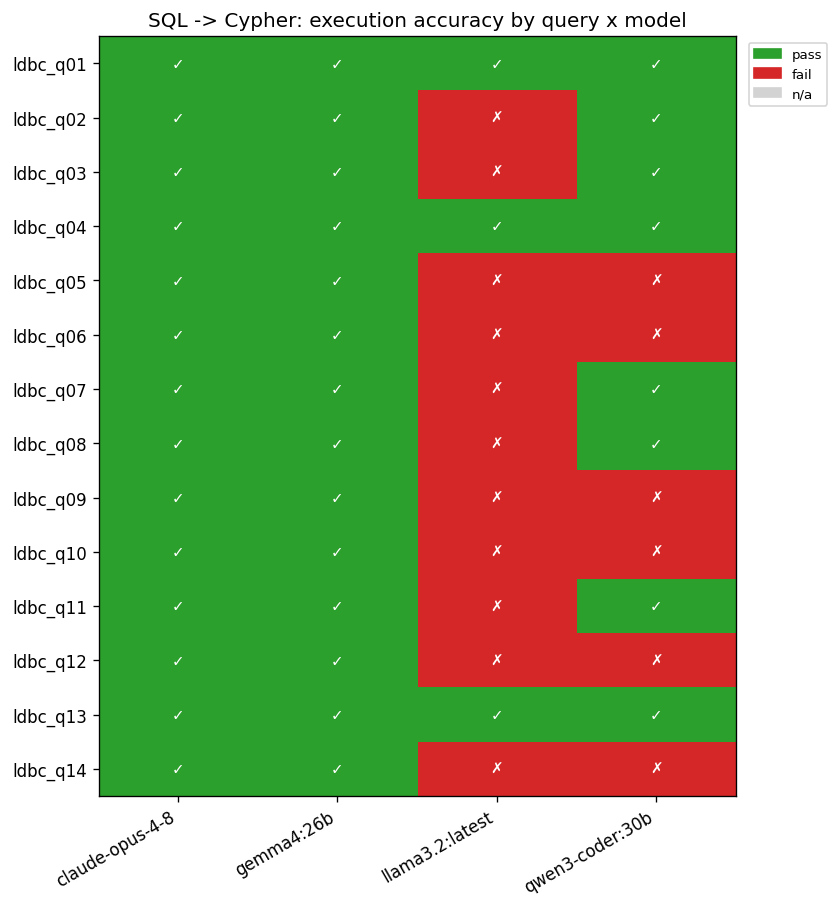

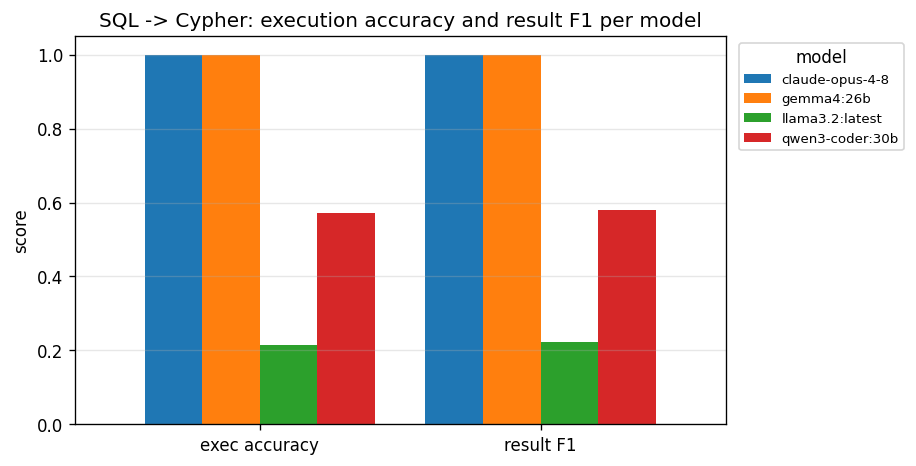

In [13]:
render_exec(exec_all[exec_all['target'] == 'cypher'], 'cypher', 'SQL -> Cypher')

### SQL → AQL

SQL -> AQL: 4 model(s): ['claude-opus-4-8', 'gemma4:26b', 'llama3.2:latest', 'qwen3-coder:30b']


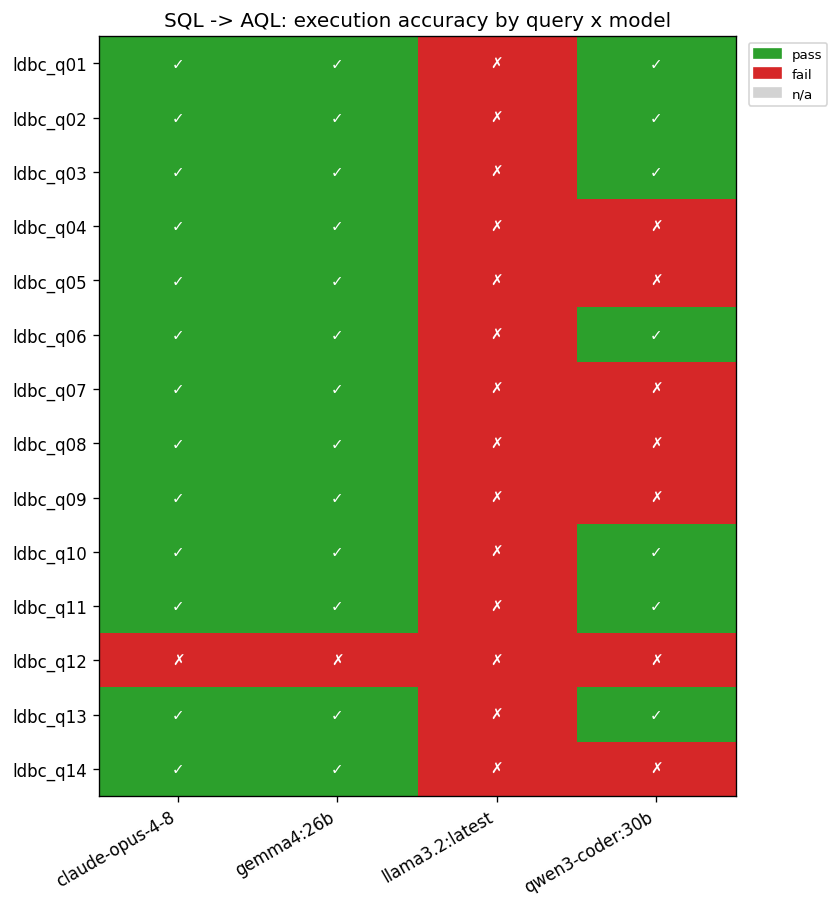

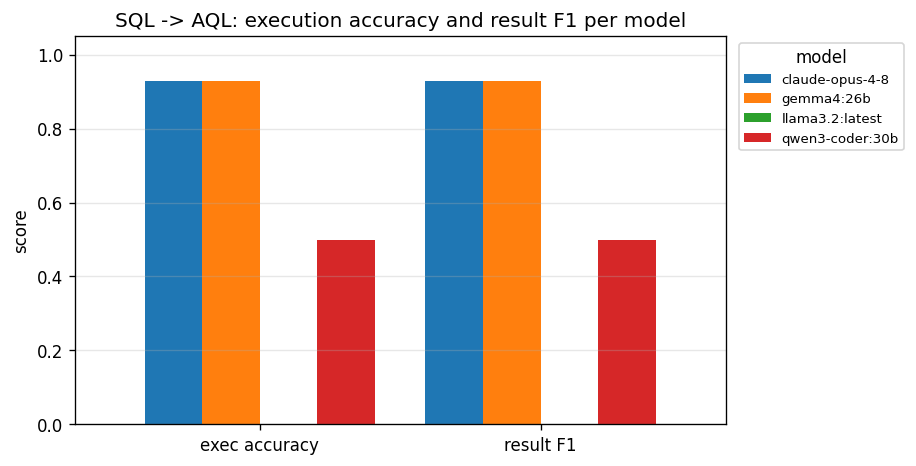

In [14]:
render_exec(exec_all[exec_all['target'] == 'aql'], 'aql', 'SQL -> AQL')

### SQL → Gremlin

SQL -> Gremlin: 4 model(s): ['claude-opus-4-8', 'gemma4:26b', 'llama3.2:latest', 'qwen3-coder:30b']


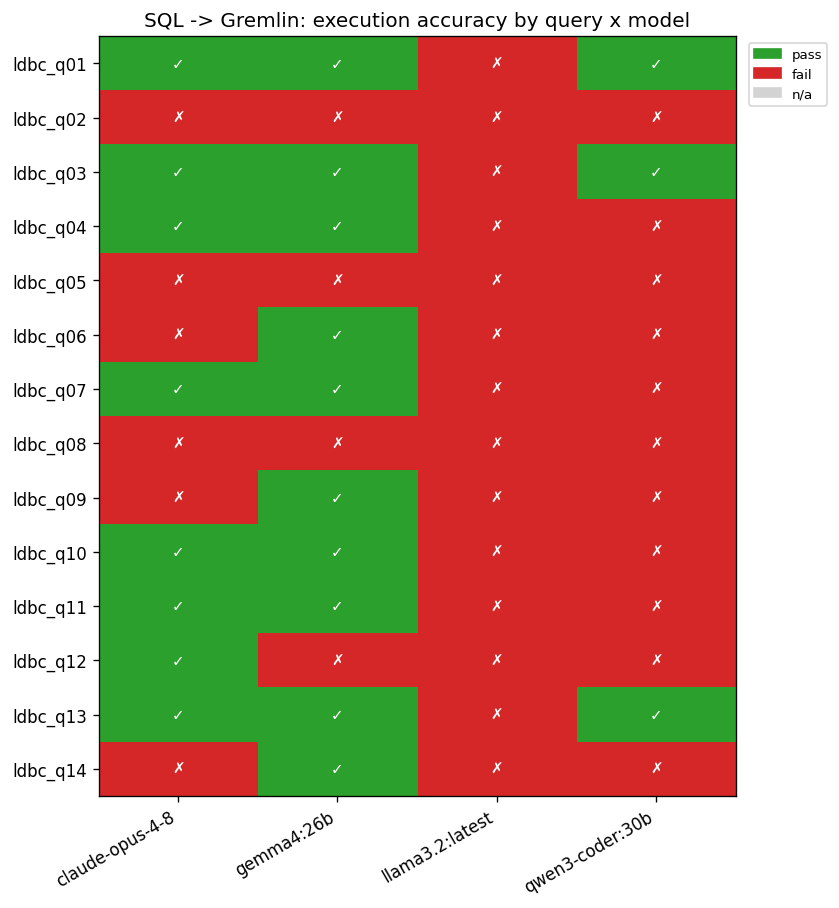

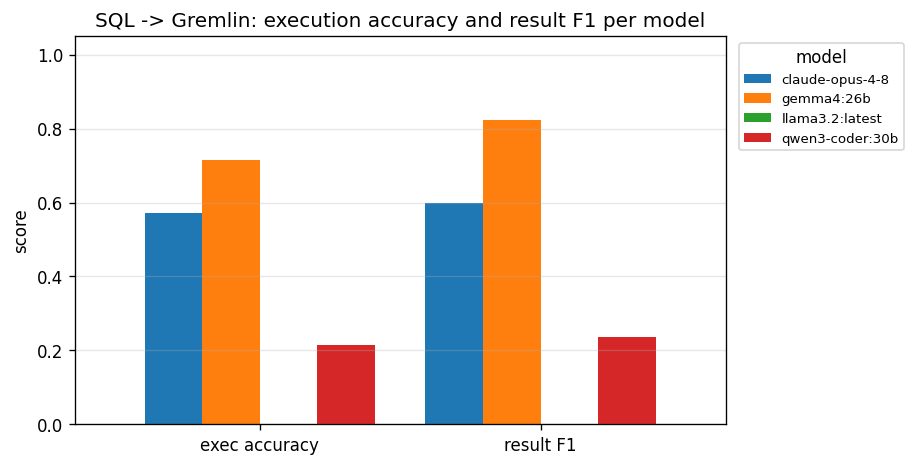

In [15]:
render_exec(exec_all[exec_all['target'] == 'gremlin'], 'gremlin', 'SQL -> Gremlin')